In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def est(t, x):
    # Parameters and constants
    cv = 0.1; D1 = 2.5; D2 = 3.0
    Dt = 0.3; F0 = 0.2; g = 9.8
    L = 100; mu = 0.001; ro = 1000

    # Constitutive relations
    A1 = np.pi*(D1**2)/4
    A2 = np.pi*(D2**2)/4
    At = np.pi*(Dt**2)/4
    Re = Dt*ro*np.abs(x[2])/mu
    F2 = cv*np.sqrt(np.abs(x[1]))

    # Friction factor
    if Re <= 2000:
        f = 64/Re
    else:
        f = 0.18/Re**0.2

    # Differential equations
    dx1 = (F0 - x[2]*At)/A1
    dx2 = (x[2]*At - F2)/A2
    dx3 = g/L*(x[0] - x[1]) - f*x[2]*np.abs(x[2])/(2*Dt)
    return [dx1, dx2, dx3]

In [3]:
# Initial conditions and integration time
x0 = [2, 5, 1e-8]
t_span = (0, 200)
t = np.linspace(t_span[0], t_span[1], 500)

# Integrate the differential equations
sol = solve_ivp(est, t_span, x0, t_eval=t, method='RK45')

# Extract results
h1, h2, v1 = sol.y

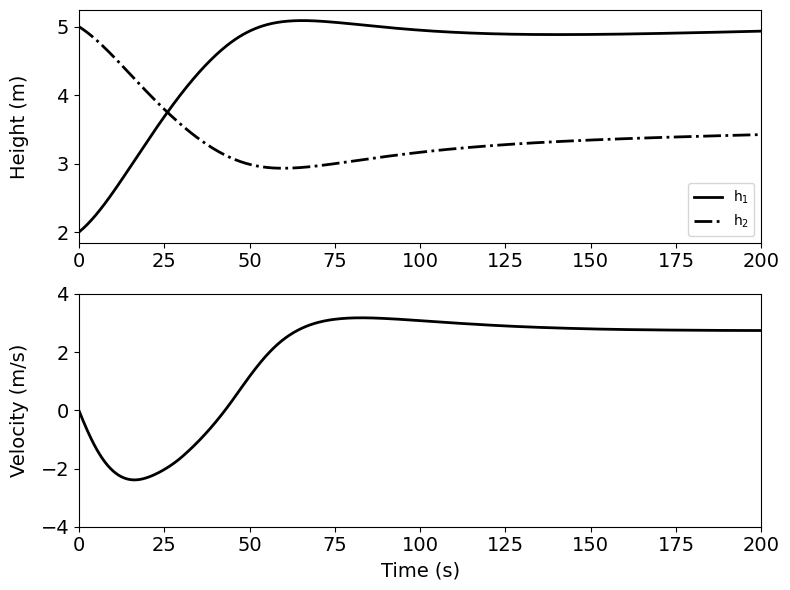

In [4]:
# Plot results
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, h1, 'k', lw=2)
plt.plot(t, h2, 'k-.', lw=2)
plt.ylabel('Height (m)', fontsize=14, labelpad=20)
plt.legend(['h$_1$', 'h$_2$'], loc='best')
plt.xlim(0, 200)
plt.tick_params(axis='both', labelsize=14)

plt.subplot(2, 1, 2)
plt.plot(t, v1, 'k', lw=2)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Velocity (m/s)', fontsize=14, labelpad=8)
plt.xlim(0, 200)
plt.ylim(-4, 4)
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()